![Alt text](https://imgur.com/orZWHly.png=80)
source: @allison_horst https://github.com/allisonhorst/penguins

On vous a sollicité pour accompagner une équipe de chercheurs qui collecte des données sur des manchots en Antarctique ! Les données sont disponibles au format CSV dans `penguins.csv`.

**Origine des données** : les données ont été collectées et mises à disposition par la Dre Kristen Gorman et la Palmer Station, Antarctica LTER, membre du Long Term Ecological Research Network.

**Le jeu de données comporte 5 colonnes.**

Column | Description
--- | ---
culmen_length_mm | longueur du culmen (mm)
culmen_depth_mm | profondeur du culmen (mm)
flipper_length_mm | longueur de la nageoire (mm)
body_mass_g | masse corporelle (g)
sex | sexe du manchot

Ils n’ont malheureusement pas pu relever l’espèce de chaque manchot, mais ils savent qu’il existe **au moins trois** espèces présentes dans la région : **Adelie**, **Chinstrap** et **Gentoo**. Votre mission est de mettre à profit vos compétences en data science pour les aider à repérer des groupes dans ce jeu de données !

In [7]:
# Import Required Packages
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Loading and examining the dataset
penguins_df = pd.read_csv("penguins.csv")
penguins_df.head()
penguins_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 332 entries, 0 to 331
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   332 non-null    float64
 1   culmen_depth_mm    332 non-null    float64
 2   flipper_length_mm  332 non-null    float64
 3   body_mass_g        332 non-null    float64
 4   sex                332 non-null    object 
dtypes: float64(4), object(1)
memory usage: 13.1+ KB


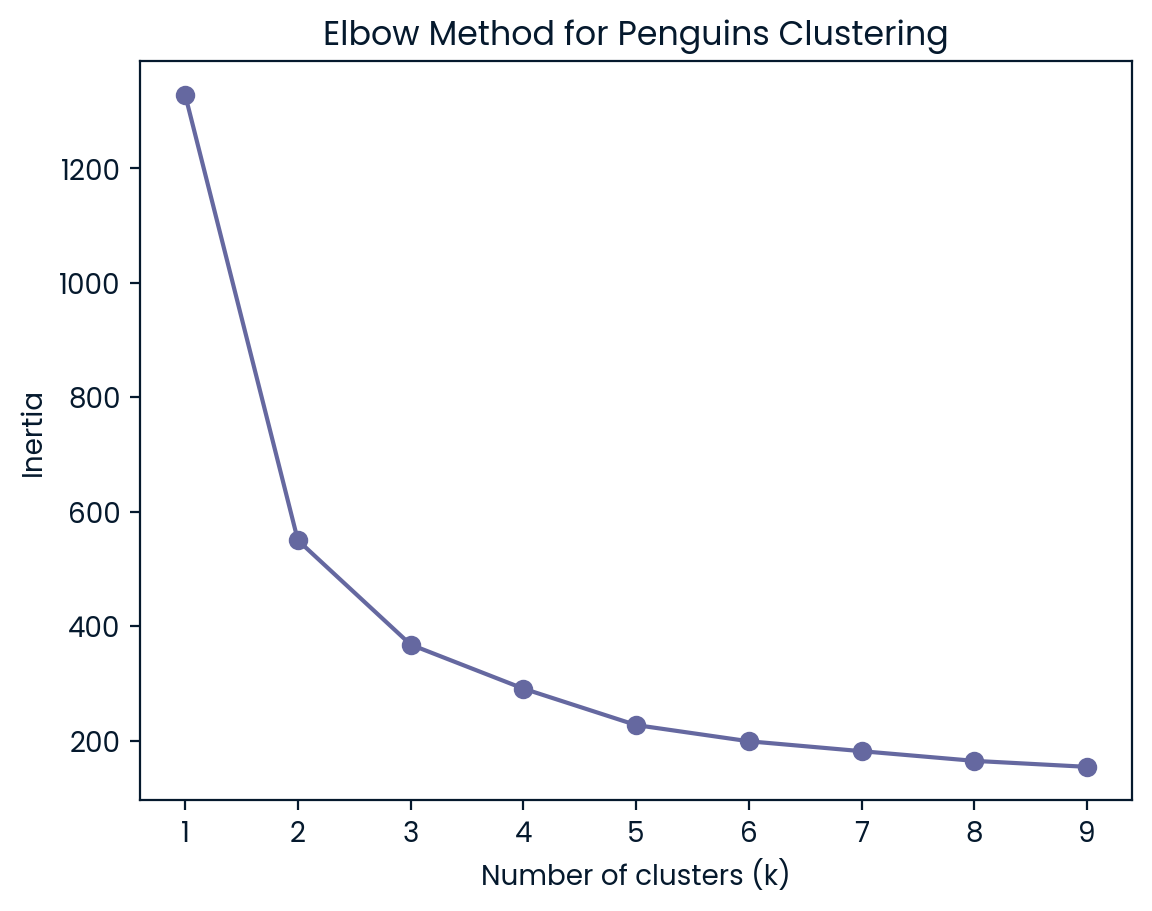

         culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g
cluster                                                                   
0               38.305469        18.098437         188.554688  3587.500000
1               47.568067        14.996639         217.235294  5092.436975
2               47.662353        18.748235         196.917647  3898.235294


In [8]:
# -----------------------------
# 2. Preprocessing
# -----------------------------

# Keep only numeric columns
numeric_cols = ['culmen_length_mm', 'culmen_depth_mm',
                'flipper_length_mm', 'body_mass_g']

penguins_num = penguins_df[numeric_cols].copy()

# Handle missing values (drop rows with missing numeric data)
penguins_num = penguins_num.dropna()

# Standardize the numeric features
scaler = StandardScaler()
scaled_penguins = scaler.fit_transform(penguins_num)

# -----------------------------
# 3. Choose a reasonable number of clusters
#    (Elbow method)
# -----------------------------
inertias = []
K_range = range(1, 10)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=0)
    model.fit(scaled_penguins)
    inertias.append(model.inertia_)

plt.plot(K_range, inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Penguins Clustering")
plt.show()

# -----------------------------
# 4. Fit KMeans with chosen number of clusters
#    (3 clusters expected biologically)
# -----------------------------
kmeans = KMeans(n_clusters=3, random_state=0)
labels = kmeans.fit_predict(scaled_penguins)

# Add cluster labels to original numeric data
penguins_num['cluster'] = labels

# -----------------------------
# 5. Compute mean values per cluster
# -----------------------------
stat_penguins = penguins_num.groupby('cluster').mean()

print(stat_penguins)